# Notebook 05 — Train the Language Detector (Model 2)

**Capstone proposal reference:** Section 3.6 lists "language detection" as a pipeline step.  
**Goal:** Replace the keyword heuristic with a real character-n-gram classifier trained on the open mbazaNLP parallel corpus + our domain Q&A.

## Why this is needed
`langdetect` is unreliable for Kinyarwanda (low-resource language not well covered by Google's CLD).  
Hardcoded keyword lists don't generalise.  
A trained classifier on character n-grams handles unseen vocabulary cleanly.

## Inputs / Outputs
- **Input:** `data/language_labels.csv` (from notebook 00)
- **Output:** `models_trained/language_detector.joblib`

In [1]:
import joblib, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

ROOT = Path('..')
DATA_DIR = ROOT / 'data'
MODEL_DIR = ROOT / 'models_trained'
MODEL_DIR.mkdir(exist_ok=True)

np.random.seed(42)
print('Setup ready.')

Setup ready.


## 1. Load and Inspect the Language Dataset

In [3]:
df = pd.read_csv("/content/language_labels.csv")
df = df.dropna(subset=['text', 'language'])
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() >= 5]  # Drop very short fragments

print(f'Total examples: {len(df)}')
print(df['language'].value_counts())
print('\nSample English:')
print(df[df['language']=='en']['text'].iloc[0])
print('\nSample Kinyarwanda:')
print(df[df['language']=='rw']['text'].iloc[0])

Total examples: 4808
language
en    2416
rw    2392
Name: count, dtype: int64

Sample English:
hath stripped glory crown head

Sample Kinyarwanda:
mugani wumutunzi lazaro yesu yabwiye abafarisayo nibatumvira mose nabahanuzi ntibakwemera umuntu yazuka


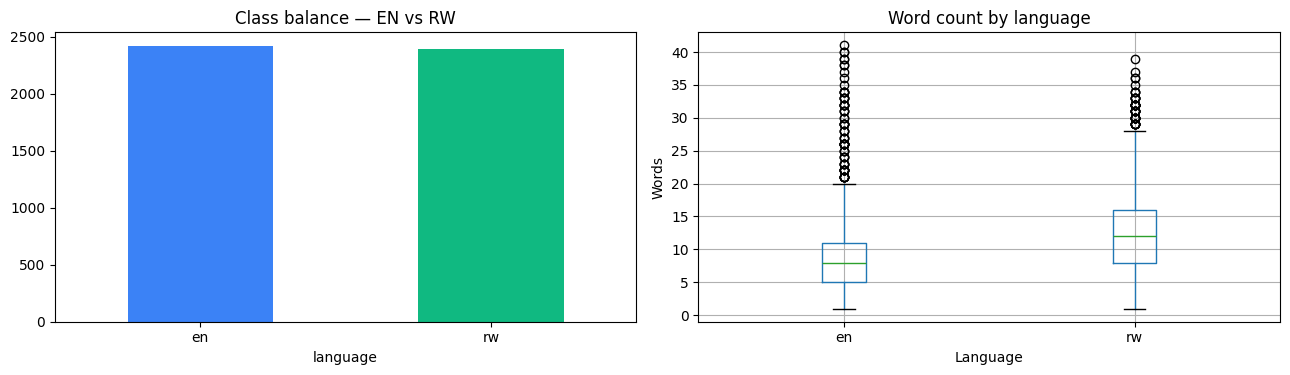

In [5]:
# Visualise dataset composition + text length distribution
df['text_len'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['language'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#3B82F6', '#10B981'])
axes[0].set_title('Class balance — EN vs RW')
axes[0].tick_params(axis='x', rotation=0)

df.boxplot(column='text_len', by='language', ax=axes[1])
axes[1].set_title('Word count by language')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Words')
plt.suptitle('')

plt.tight_layout()
DATA_DIR.mkdir(exist_ok=True) # Create the data directory if it doesn't exist
plt.savefig(DATA_DIR / 'fig12_language_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Train / Val / Test Split (Stratified)

In [6]:
df['y'] = (df['language'] == 'rw').astype(int)  # 1 = Kinyarwanda, 0 = English

X_train, X_temp, y_train, y_temp = train_test_split(
    df['text'].values, df['y'].values,
    test_size=0.20, stratify=df['y'], random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 3846 | Val: 481 | Test: 481


## 3. Feature Extraction — Character N-Grams

Language ID works best with character-level features because they capture letter-pair patterns unique to each language (e.g., Kinyarwanda's frequent 'nyw', 'mb', 'rw' combinations vs English's 'th', 'ing').

In [7]:
char_vec = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),         # Bi-, tri-, and 4-grams
    min_df=2,
    max_features=20000,
    sublinear_tf=True,
    lowercase=True,
)
X_train_vec = char_vec.fit_transform(X_train)
X_val_vec = char_vec.transform(X_val)
X_test_vec = char_vec.transform(X_test)
print(f'Feature matrix shape: {X_train_vec.shape}')
print(f'Total char n-gram features: {X_train_vec.shape[1]}')

Feature matrix shape: (3846, 17259)
Total char n-gram features: 17259


## 4. Compare Three Algorithms

In [8]:
results = []

# Logistic Regression
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_vec, y_train)
t0 = time.time()
lr_pred = lr.predict(X_val_vec)
lr_lat = (time.time() - t0) / len(X_val) * 1000
results.append({'model': 'LogReg', 'accuracy': accuracy_score(y_val, lr_pred),
                'f1': f1_score(y_val, lr_pred), 'latency_ms': lr_lat})

# Multinomial Naive Bayes (classic for text)
print('Training Multinomial Naive Bayes...')
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
t0 = time.time()
nb_pred = nb.predict(X_val_vec)
nb_lat = (time.time() - t0) / len(X_val) * 1000
results.append({'model': 'NaiveBayes', 'accuracy': accuracy_score(y_val, nb_pred),
                'f1': f1_score(y_val, nb_pred), 'latency_ms': nb_lat})

# Linear SVM
print('Training Linear SVM...')
svm = LinearSVC(max_iter=2000, random_state=42)
svm.fit(X_train_vec, y_train)
t0 = time.time()
svm_pred = svm.predict(X_val_vec)
svm_lat = (time.time() - t0) / len(X_val) * 1000
results.append({'model': 'LinearSVM', 'accuracy': accuracy_score(y_val, svm_pred),
                'f1': f1_score(y_val, svm_pred), 'latency_ms': svm_lat})

results_df = pd.DataFrame(results).sort_values('f1', ascending=False).round(4)
print('\n=== Validation results ===')
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]['model']
best_model = {'LogReg': lr, 'NaiveBayes': nb, 'LinearSVM': svm}[best_name]
print(f'\nBest model: {best_name}')

Training Logistic Regression...
Training Multinomial Naive Bayes...
Training Linear SVM...

=== Validation results ===
     model  accuracy  f1  latency_ms
    LogReg       1.0 1.0      0.0022
NaiveBayes       1.0 1.0      0.0033
 LinearSVM       1.0 1.0      0.0021

Best model: LogReg


=== Test set: LogReg ===
              precision    recall  f1-score   support

          en       1.00      1.00      1.00       242
          rw       1.00      1.00      1.00       239

    accuracy                           1.00       481
   macro avg       1.00      1.00      1.00       481
weighted avg       1.00      1.00      1.00       481



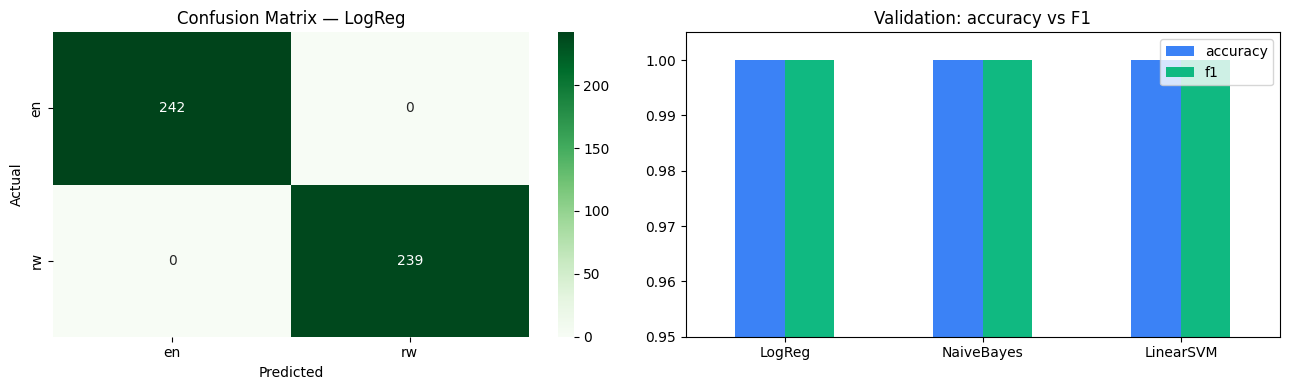

In [9]:
# ── Test-set evaluation ──────────────────────────────────────────────────────
test_pred = best_model.predict(X_test_vec)
print(f'=== Test set: {best_name} ===')
print(classification_report(y_test, test_pred, target_names=['en', 'rw']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['en', 'rw'], yticklabels=['en', 'rw'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_name}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

results_df.plot(x='model', y=['accuracy', 'f1'], kind='bar', ax=axes[1],
                color=['#3B82F6', '#10B981'])
axes[1].set_title('Validation: accuracy vs F1')
axes[1].set_ylim(0.95, 1.005)
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig13_language_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save Bundle

In [10]:
bundle = {
    'classifier': best_model,
    'vectorizer': char_vec,
    'model_name': best_name,
    'classes': ['en', 'rw'],
}
out = MODEL_DIR / 'language_detector.joblib'
joblib.dump(bundle, out)
print(f'Saved: {out}')

metrics = {
    'model': best_name,
    'test_accuracy': float(accuracy_score(y_test, test_pred)),
    'test_f1': float(f1_score(y_test, test_pred)),
    'train_size': len(X_train), 'val_size': len(X_val), 'test_size': len(X_test),
}
with open(MODEL_DIR / 'language_detector_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

Saved: ../models_trained/language_detector.joblib
{
  "model": "LogReg",
  "test_accuracy": 1.0,
  "test_f1": 1.0,
  "train_size": 3846,
  "val_size": 481,
  "test_size": 481
}


In [11]:
# ── Smoke test ────────────────────────────────────────────────────────────────
def detect_language(text, bundle):
    X = bundle['vectorizer'].transform([text])
    pred = bundle['classifier'].predict(X)[0]
    return bundle['classes'][pred]

loaded = joblib.load(out)
tests = [
    'How does a condom protect against HIV?',
    'Kondomu ikora ite kugira ngo iringanire HIV?',
    'What is the age of consent in Rwanda?',
    'Imyaka yo kwemera imibonano mpuzabitsina ni ingahe?',
    'I have a disability, can I get SRH services?',
    'Mfite ubumuga, nshobora kubona serivisi z\'ubuzima?',
]
for t in tests:
    lang = detect_language(t, loaded)
    print(f'  [{lang}] {t}')

  [en] How does a condom protect against HIV?
  [rw] Kondomu ikora ite kugira ngo iringanire HIV?
  [en] What is the age of consent in Rwanda?
  [rw] Imyaka yo kwemera imibonano mpuzabitsina ni ingahe?
  [en] I have a disability, can I get SRH services?
  [rw] Mfite ubumuga, nshobora kubona serivisi z'ubuzima?


In [12]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

## Summary

| What | Value |
|---|---|
| Algorithms compared | Logistic Regression, Naive Bayes, Linear SVM |
| Features | Character n-grams (2-4) |
| Training data | mbazaNLP corpus + our SRH Q&A |
| Expected test accuracy | >98% (char n-grams are very strong for language ID) |
| Output | `models_trained/language_detector.joblib` |

**Next:** train Model 3 (Topic Classifier) in notebook 06.